# Montgomery TB Classification: CNN Binary Classifier

This notebook trains a binary chest X-ray classifier on the NLM Montgomery County set. Unlike the segmentation and detection notebooks, it does not use the manual lung masks as targets: the class label is derived directly from each image filename, where `_0` means no tuberculosis and `_1` means tuberculosis.

## 0. Setup

In [1]:
from pathlib import Path
import random
import warnings

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams["figure.figsize"] = (8, 8)
plt.rcParams["image.cmap"] = "gray"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATASET_DIR = Path("/media/felipe/KINGSTON/datasets/NLM-MontgomeryCXRSet/MontgomerySet")
IMAGE_DIR = DATASET_DIR / "CXR_png"
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

assert IMAGE_DIR.exists(), f"Image directory not found: {IMAGE_DIR}"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {DEVICE}")
print(f"torch: {torch.__version__}; cuda build: {torch.version.cuda}")


device: cuda
torch: 2.11.0+cu128; cuda build: 12.8


/home/felipe/miniconda3/envs/esr-segmentation-gpu/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Build Image Index

In [2]:
def disease_label_from_id(image_id: str) -> int:
    suffix = image_id.rsplit("_", 1)[-1]
    if suffix not in {"0", "1"}:
        raise ValueError(f"Expected image id to end with _0 or _1, got {image_id!r}")
    return int(suffix)


def build_montgomery_classification_index() -> pd.DataFrame:
    rows = []
    for image_path in sorted(IMAGE_DIR.glob("*.png")):
        image_id = image_path.stem
        label = disease_label_from_id(image_id)
        rows.append({
            "ImageId": image_id,
            "image_path": image_path,
            "disease_label": label,
            "label_name": "TB" if label == 1 else "No TB",
        })
    return pd.DataFrame(rows)


images_df = build_montgomery_classification_index()
assert not images_df.empty, "No Montgomery PNG images found."

print(f"images: {len(images_df):,}")
images_df["label_name"].value_counts().rename_axis("class").to_frame("images")


images: 138


,images
class,
No TB,80
TB,58


## 2. Image Loading And Label Check

In [3]:
def read_grayscale_png(path: Path) -> np.ndarray:
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(path)
    return image


def normalize_percentile(image: np.ndarray, lower: float = 1, upper: float = 99, eps: float = 1e-7) -> np.ndarray:
    image = image.astype(np.float32)
    lo, hi = np.percentile(image, [lower, upper])
    image = np.clip(image, lo, hi)
    return ((image - lo) / (hi - lo + eps)).astype(np.float32)


def image_and_label(image_id: str) -> tuple[np.ndarray, int]:
    row = images_df.loc[images_df["ImageId"] == image_id].iloc[0]
    image = read_grayscale_png(row.image_path)
    label = int(row.disease_label)
    return image, label


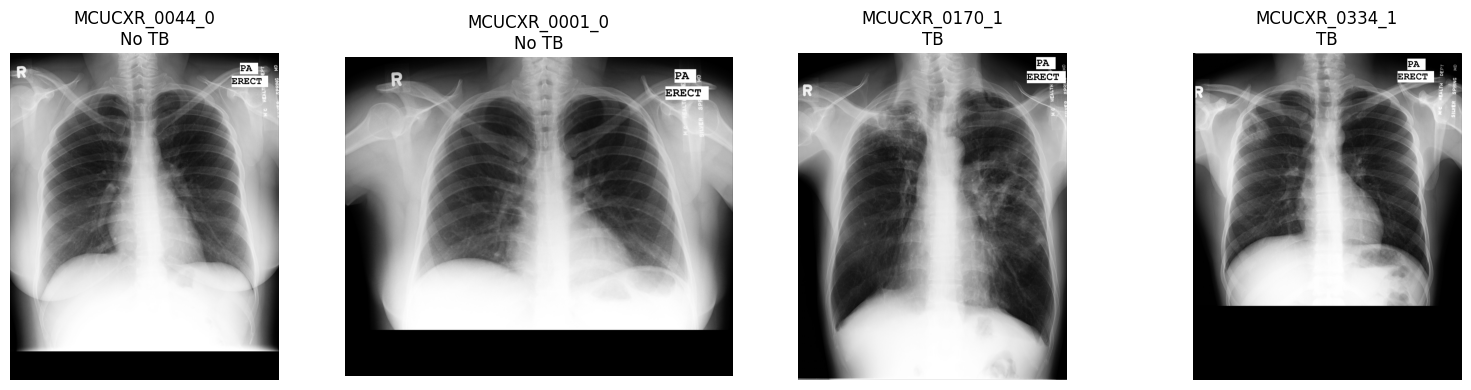

In [4]:
sample_rows = images_df.groupby("disease_label", group_keys=False).sample(2, random_state=SEED)
fig, axes = plt.subplots(1, len(sample_rows), figsize=(4 * len(sample_rows), 4))
if len(sample_rows) == 1:
    axes = [axes]

for ax, row in zip(axes, sample_rows.itertuples(index=False)):
    image = normalize_percentile(read_grayscale_png(row.image_path))
    ax.imshow(image, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"{row.ImageId}\n{row.label_name}")
    ax.axis("off")

plt.tight_layout()


## 3. Train/Validation Split

In [5]:
def stratified_image_split(df: pd.DataFrame, valid_fraction: float = 0.2, seed: int = SEED):
    rng = np.random.default_rng(seed)
    train_ids, valid_ids = [], []
    for _, group in df.groupby("disease_label"):
        ids = group["ImageId"].to_numpy().copy()
        rng.shuffle(ids)
        n_valid = max(1, int(round(len(ids) * valid_fraction)))
        valid_ids.extend(ids[:n_valid])
        train_ids.extend(ids[n_valid:])
    train_ids = np.array(train_ids)
    valid_ids = np.array(valid_ids)
    rng.shuffle(train_ids)
    rng.shuffle(valid_ids)
    return train_ids, valid_ids


train_ids, valid_ids = stratified_image_split(images_df)
label_lookup = images_df.set_index("ImageId")["disease_label"]
pd.DataFrame({
    "split": ["all", "train", "valid"],
    "images": [len(images_df), len(train_ids), len(valid_ids)],
    "tb_fraction": [
        images_df["disease_label"].mean(),
        label_lookup.loc[train_ids].mean(),
        label_lookup.loc[valid_ids].mean(),
    ],
})


,split,images,tb_fraction
0,all,138,0.420290
1,train,110,0.418182
2,valid,28,0.428571


## 4. PyTorch Classification Dataset

In [6]:
def make_train_transform(size: int) -> A.Compose:
    return A.Compose([
        A.Resize(height=size, width=size),
        A.ShiftScaleRotate(
            shift_limit=0.03,
            scale_limit=0.08,
            rotate_limit=7,
            p=0.5,
            border_mode=cv2.BORDER_CONSTANT,
        ),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.08, contrast_limit=0.08, p=0.35),
    ])


def make_valid_transform(size: int) -> A.Compose:
    return A.Compose([
        A.Resize(height=size, width=size),
    ])


class MontgomeryTBClassificationDataset(Dataset):
    def __init__(self, image_ids, metadata: pd.DataFrame, transform: A.Compose | None = None):
        self.image_ids = list(image_ids)
        self.metadata = metadata.set_index("ImageId")
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        row = self.metadata.loc[image_id]
        image = normalize_percentile(read_grayscale_png(row.image_path))
        label = np.array([row.disease_label], dtype=np.float32)

        if self.transform is not None:
            transformed = self.transform(image=image)
            image = transformed["image"].astype(np.float32)

        image = np.repeat(image[..., None], 3, axis=-1)
        image = (image - IMAGENET_MEAN) / IMAGENET_STD
        image = np.ascontiguousarray(image.transpose(2, 0, 1))

        image = torch.from_numpy(image).float()
        label = torch.from_numpy(label)
        return image, label, image_id


In [7]:
IMAGE_SIZE = 384
BATCH_SIZE = 16
NUM_WORKERS = 4

MAX_TRAIN_IMAGES = None
MAX_VALID_IMAGES = None

train_transform = make_train_transform(IMAGE_SIZE)
valid_transform = make_valid_transform(IMAGE_SIZE)

train_ids_run = train_ids[:MAX_TRAIN_IMAGES] if MAX_TRAIN_IMAGES else train_ids
valid_ids_run = valid_ids[:MAX_VALID_IMAGES] if MAX_VALID_IMAGES else valid_ids

train_ds = MontgomeryTBClassificationDataset(train_ids_run, images_df, transform=train_transform)
valid_ds = MontgomeryTBClassificationDataset(valid_ids_run, images_df, transform=valid_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

images, labels, image_ids = next(iter(train_loader))
images.shape, labels.shape, image_ids[:2]


(torch.Size([16, 3, 384, 384]),
 torch.Size([16, 1]),
 (np.str_('MCUCXR_0311_1'), np.str_('MCUCXR_0011_0')))

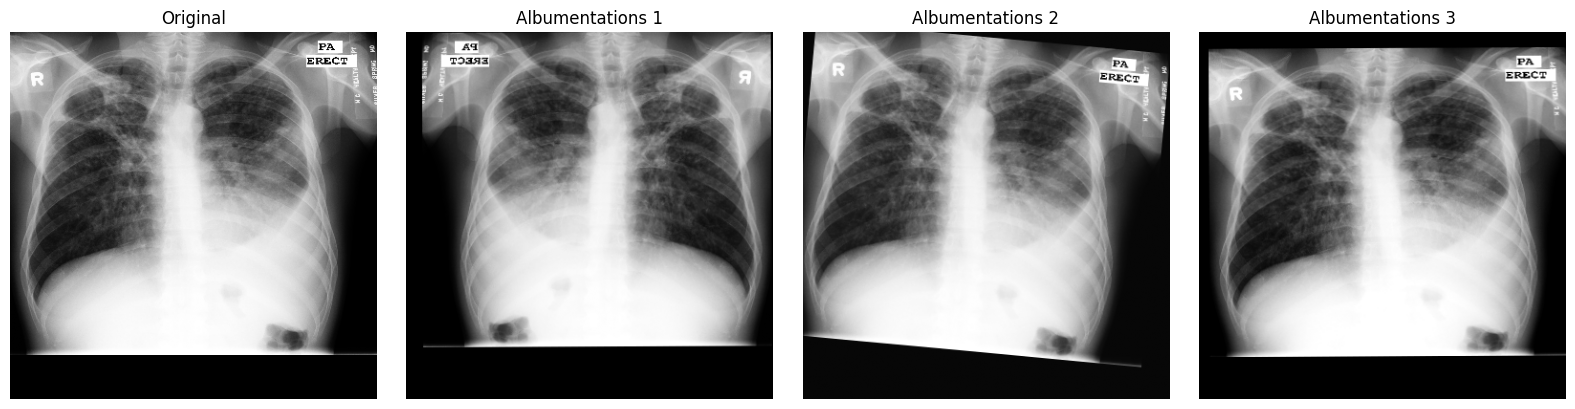

In [8]:
preview_id = images_df.sample(1, random_state=SEED).iloc[0].ImageId
preview_image, preview_label = image_and_label(preview_id)
preview_image = normalize_percentile(preview_image).astype(np.float32)

base = valid_transform(image=preview_image)["image"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for col in range(4):
    if col == 0:
        image_aug = base
        title = "Original"
    else:
        image_aug = train_transform(image=preview_image)["image"]
        title = f"Albumentations {col}"
    axes[col].imshow(image_aug, cmap="gray", vmin=0, vmax=1)
    axes[col].set_title(title)
    axes[col].axis("off")
plt.tight_layout()


## 5. CNN Binary Classifier

In [9]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, dropout: float = 0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class MontgomeryTBClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128, dropout=0.05),
            ConvBlock(128, 256, dropout=0.10),
            ConvBlock(256, 384, dropout=0.10),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.30),
            nn.Linear(384, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.20),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)


model = MontgomeryTBClassifier().to(DEVICE)
with torch.no_grad():
    test_logits = model(images[:2].to(DEVICE))
test_logits.shape


torch.Size([2, 1])

## 6. Train

In [10]:
def binary_auc(probs: np.ndarray, targets: np.ndarray) -> float:
    probs = np.asarray(probs, dtype=np.float32).reshape(-1)
    targets = np.asarray(targets, dtype=np.int64).reshape(-1)
    pos = probs[targets == 1]
    neg = probs[targets == 0]
    if len(pos) == 0 or len(neg) == 0:
        return float("nan")
    comparisons = pos[:, None] - neg[None, :]
    return float((comparisons > 0).mean() + 0.5 * (comparisons == 0).mean())


def classification_metrics_from_logits(logits: torch.Tensor, targets: torch.Tensor, threshold: float = 0.5) -> dict[str, float]:
    probs = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
    labels = targets.detach().cpu().numpy().reshape(-1).astype(np.int64)
    preds = (probs >= threshold).astype(np.int64)

    tp = int(((preds == 1) & (labels == 1)).sum())
    tn = int(((preds == 0) & (labels == 0)).sum())
    fp = int(((preds == 1) & (labels == 0)).sum())
    fn = int(((preds == 0) & (labels == 1)).sum())

    accuracy = (tp + tn) / max(1, tp + tn + fp + fn)
    precision = tp / max(1, tp + fp)
    recall = tp / max(1, tp + fn)
    f1 = 2 * precision * recall / max(1e-7, precision + recall)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": binary_auc(probs, labels),
    }


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss = 0.0
    total_images = 0
    all_logits = []
    all_targets = []

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, labels, _ in tqdm(loader, leave=False):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size
            total_images += batch_size
            all_logits.append(logits.detach().cpu())
            all_targets.append(labels.detach().cpu())

    all_logits = torch.cat(all_logits, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    metrics = classification_metrics_from_logits(all_logits, all_targets)
    metrics["loss"] = total_loss / max(1, total_images)
    return metrics


In [12]:
EPOCHS = 10
LEARNING_RATE = 1e-3
MIN_LEARNING_RATE = 1e-5
CHECKPOINT_PATH = RESULTS_DIR / "cnn_montgomery_tb_classifier.pt"

train_labels = label_lookup.loc[train_ids_run].to_numpy()
positive_count = int(train_labels.sum())
negative_count = int(len(train_labels) - positive_count)
pos_weight = torch.tensor([negative_count / max(1, positive_count)], device=DEVICE, dtype=torch.float32)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=MIN_LEARNING_RATE)
history = []
best_valid_auc = -float("inf")
best_valid_loss = float("inf")

print(f"positive_count={positive_count}, negative_count={negative_count}, pos_weight={pos_weight.item():.3f}")

for epoch in range(1, EPOCHS + 1):
    train_metrics = run_epoch(model, train_loader, criterion, optimizer)
    valid_metrics = run_epoch(model, valid_loader, criterion)
    current_lr = optimizer.param_groups[0]["lr"]
    history.append({"epoch": epoch, "lr": current_lr, **{f"train_{k}": v for k, v in train_metrics.items()}, **{f"valid_{k}": v for k, v in valid_metrics.items()}})

    valid_auc = valid_metrics["auc"]
    is_better = valid_auc > best_valid_auc or (np.isnan(valid_auc) and valid_metrics["loss"] < best_valid_loss)
    if is_better:
        best_valid_auc = valid_auc
        best_valid_loss = valid_metrics["loss"]
        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "history": history,
            "image_size": IMAGE_SIZE,
            "pos_weight": pos_weight.detach().cpu(),
        }, CHECKPOINT_PATH)

    scheduler.step()
    print(
        f"Epoch {epoch:02d}/{EPOCHS} "
        f"lr={current_lr:.2e} "
        f"train_loss={train_metrics['loss']:.4f} train_f1={train_metrics['f1']:.4f} train_auc={train_metrics['auc']:.4f} "
        f"valid_loss={valid_metrics['loss']:.4f} valid_f1={valid_metrics['f1']:.4f} valid_auc={valid_metrics['auc']:.4f}"
    )

print(f"best checkpoint: {CHECKPOINT_PATH}")


positive_count=46, negative_count=64, pos_weight=1.391


Epoch 01/10 lr=1.00e-03 train_loss=0.8253 train_f1=0.5273 train_auc=0.5380 valid_loss=0.9406 valid_f1=0.0000 valid_auc=0.8698


Epoch 02/10 lr=9.76e-04 train_loss=0.7964 train_f1=0.2941 train_auc=0.5914 valid_loss=1.2302 valid_f1=0.0000 valid_auc=0.7448


Epoch 03/10 lr=9.05e-04 train_loss=0.7861 train_f1=0.5893 train_auc=0.6257 valid_loss=0.7969 valid_f1=0.0000 valid_auc=0.7604


Epoch 04/10 lr=7.96e-04 train_loss=0.7878 train_f1=0.5556 train_auc=0.5921 valid_loss=0.7614 valid_f1=0.6471 valid_auc=0.7969


...

Epoch 06/10 lr=5.05e-04 train_loss=0.7413 train_f1=0.6355 train_auc=0.6882 valid_loss=0.8178 valid_f1=0.6154 valid_auc=0.8281


Epoch 07/10 lr=3.52e-04 train_loss=0.7273 train_f1=0.5800 train_auc=0.7011 valid_loss=0.7819 valid_f1=0.6154 valid_auc=0.7188


Epoch 08/10 lr=2.14e-04 train_loss=0.6628 train_f1=0.7010 train_auc=0.8088 valid_loss=0.7816 valid_f1=0.6154 valid_auc=0.7500


Epoch 09/10 lr=1.05e-04 train_loss=0.6694 train_f1=0.7027 train_auc=0.7870 valid_loss=0.8114 valid_f1=0.6154 valid_auc=0.8177


Epoch 10/10 lr=3.42e-05 train_loss=0.6776 train_f1=0.6857 train_auc=0.7721 valid_loss=0.7408 valid_f1=0.6316 valid_auc=0.8281
best checkpoint: results/cnn_montgomery_tb_classifier.pt


## 7. Validate And Preview Predictions

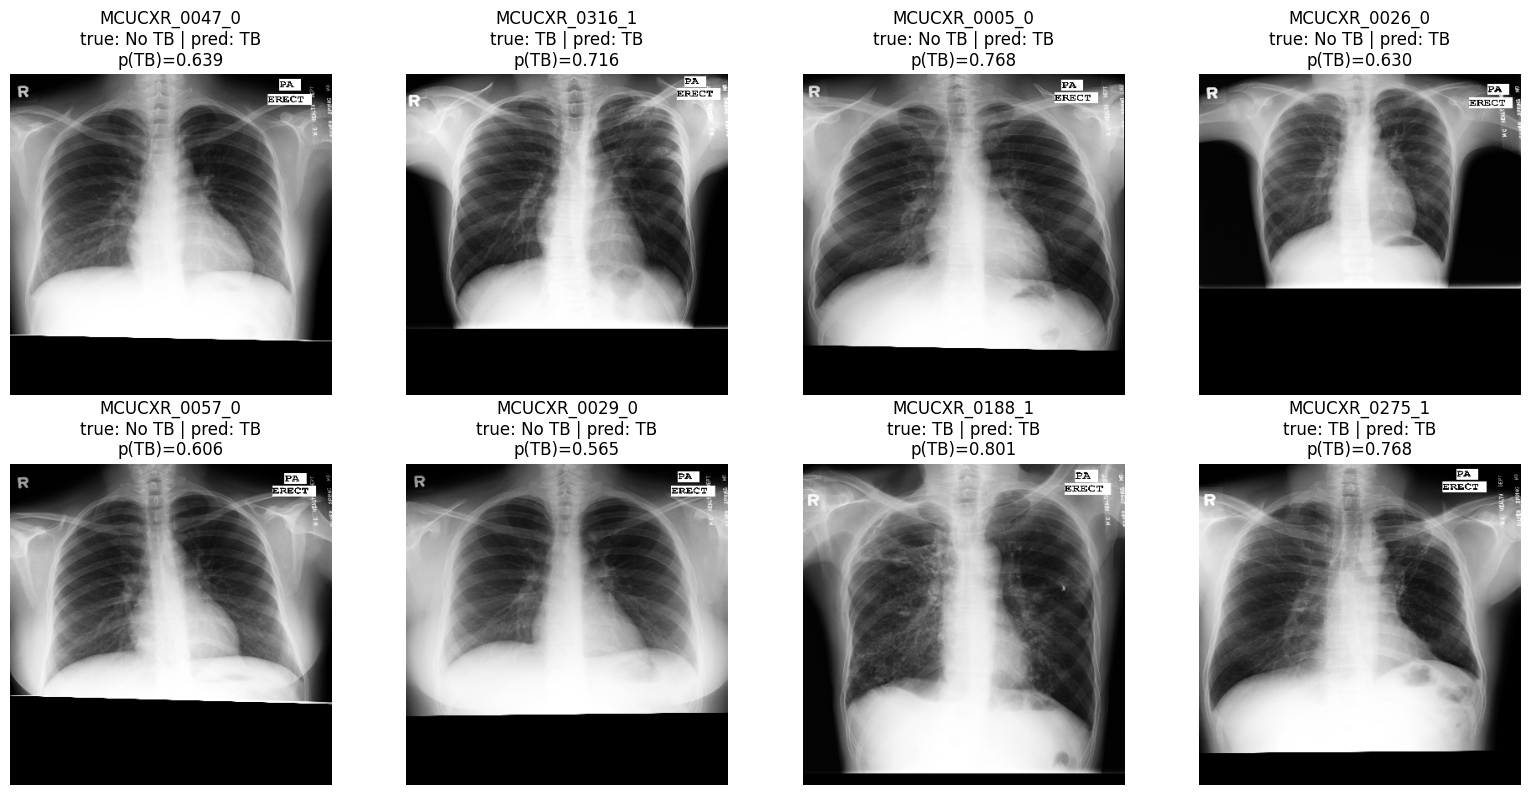

In [15]:
@torch.no_grad()
def predict_batch(model, images: torch.Tensor, threshold: float = 0.5) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    probs = torch.sigmoid(model(images.to(DEVICE))).cpu().numpy().reshape(-1)
    preds = (probs >= threshold).astype(np.int64)
    return preds, probs


preview_valid_ids = valid_ids[:max(BATCH_SIZE, 4)]
preview_valid_ds = MontgomeryTBClassificationDataset(preview_valid_ids, images_df, transform=valid_transform)
preview_valid_loader = DataLoader(
    preview_valid_ds,
    batch_size=min(BATCH_SIZE, len(preview_valid_ds)),
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

images, labels, image_ids = next(iter(preview_valid_loader))
pred_labels, pred_probs = predict_batch(model, images)
true_labels = labels.numpy().reshape(-1).astype(np.int64)

n = min(8, images.shape[0])
cols = min(4, n)
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = np.array(axes).reshape(-1)

for i in range(n):
    image = images[i].numpy().transpose(1, 2, 0)
    image = image * IMAGENET_STD + IMAGENET_MEAN
    image = np.clip(image[..., 0], 0, 1)
    true_name = "TB" if true_labels[i] == 1 else "No TB"
    pred_name = "TB" if pred_labels[i] == 1 else "No TB"
    axes[i].imshow(image, cmap="gray", vmin=0, vmax=1)
    axes[i].set_title(f"{image_ids[i]}\ntrue: {true_name} | pred: {pred_name}\np(TB)={pred_probs[i]:.3f}")
    axes[i].axis("off")

for ax in axes[n:]:
    ax.axis("off")
plt.tight_layout()


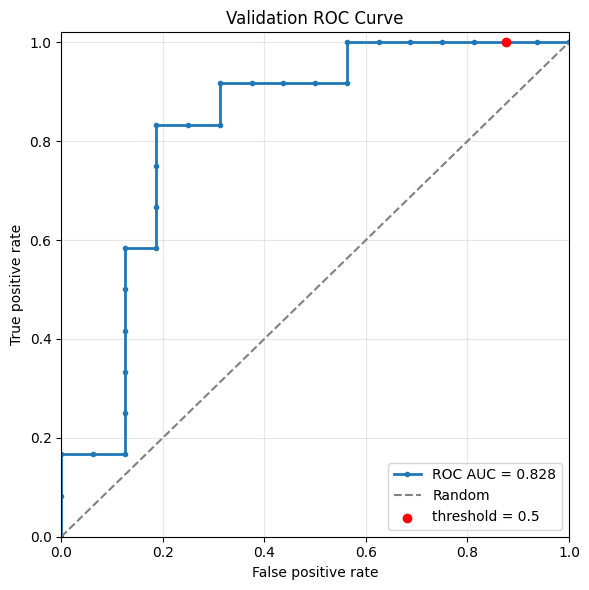

In [16]:
@torch.no_grad()
def collect_validation_predictions(model, loader) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    all_probs = []
    all_targets = []
    for images, labels, _ in tqdm(loader, leave=False):
        images = images.to(DEVICE, non_blocking=True)
        logits = model(images)
        probs = torch.sigmoid(logits).cpu().numpy().reshape(-1)
        targets = labels.numpy().reshape(-1).astype(np.int64)
        all_probs.append(probs)
        all_targets.append(targets)
    return np.concatenate(all_probs), np.concatenate(all_targets)


def roc_curve_points(probs: np.ndarray, targets: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    probs = np.asarray(probs, dtype=np.float32).reshape(-1)
    targets = np.asarray(targets, dtype=np.int64).reshape(-1)
    thresholds = np.r_[np.inf, np.sort(np.unique(probs))[::-1], -np.inf]
    positives = max(1, int((targets == 1).sum()))
    negatives = max(1, int((targets == 0).sum()))

    tpr = []
    fpr = []
    for threshold in thresholds:
        preds = probs >= threshold
        tp = int(((preds == 1) & (targets == 1)).sum())
        fp = int(((preds == 1) & (targets == 0)).sum())
        tpr.append(tp / positives)
        fpr.append(fp / negatives)
    return np.asarray(fpr), np.asarray(tpr), thresholds


def roc_point_at_threshold(probs: np.ndarray, targets: np.ndarray, threshold: float = 0.5) -> tuple[float, float]:
    preds = probs >= threshold
    positives = max(1, int((targets == 1).sum()))
    negatives = max(1, int((targets == 0).sum()))
    tp = int(((preds == 1) & (targets == 1)).sum())
    fp = int(((preds == 1) & (targets == 0)).sum())
    return fp / negatives, tp / positives


valid_probs, valid_targets = collect_validation_predictions(model, valid_loader)
valid_auc = binary_auc(valid_probs, valid_targets)
fpr, tpr, roc_thresholds = roc_curve_points(valid_probs, valid_targets)
threshold_fpr, threshold_tpr = roc_point_at_threshold(valid_probs, valid_targets, threshold=0.5)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, marker=".", linewidth=2, label=f"ROC AUC = {valid_auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
ax.scatter([threshold_fpr], [threshold_tpr], color="red", zorder=3, label="threshold = 0.5")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Validation ROC Curve")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()


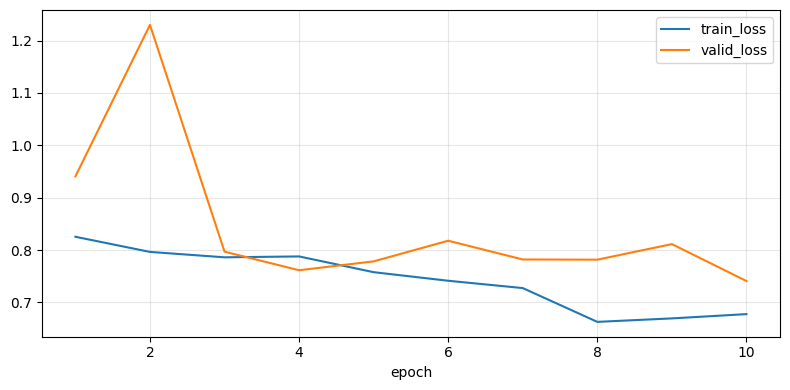

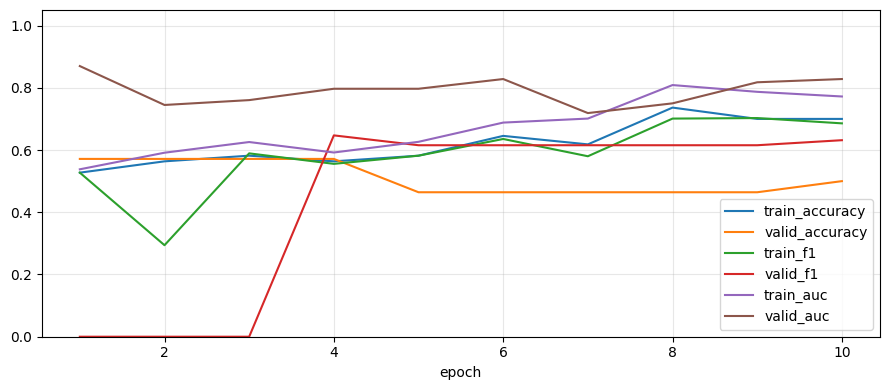

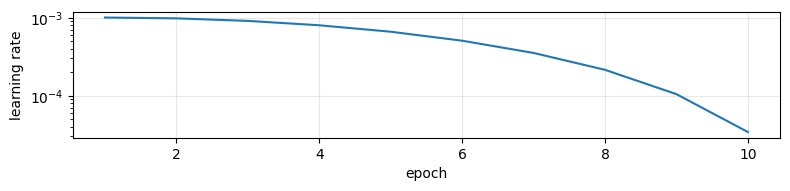

In [17]:
history_df = pd.DataFrame(history)
history_df.plot(x="epoch", y=["train_loss", "valid_loss"], figsize=(8, 4))
plt.grid(True, alpha=0.3)
plt.tight_layout()

metric_columns = ["train_accuracy", "valid_accuracy", "train_f1", "valid_f1", "train_auc", "valid_auc"]
history_df.plot(x="epoch", y=metric_columns, figsize=(9, 4))
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()

history_df.plot(x="epoch", y="lr", figsize=(8, 2), logy=True, legend=False)
plt.ylabel("learning rate")
plt.grid(True, alpha=0.3)
plt.tight_layout()
